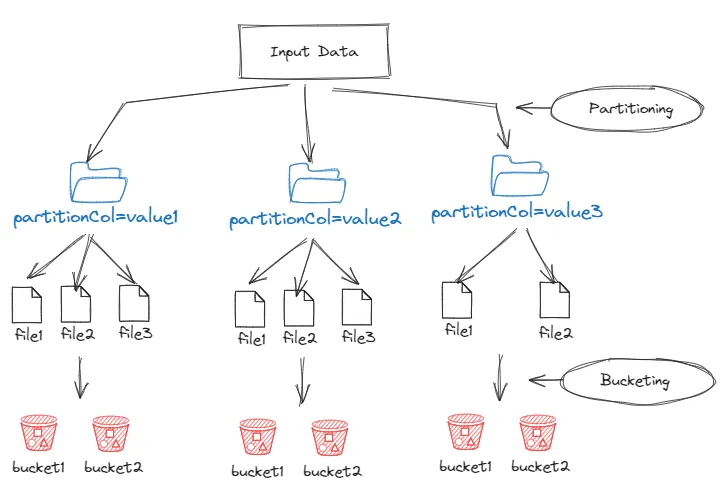

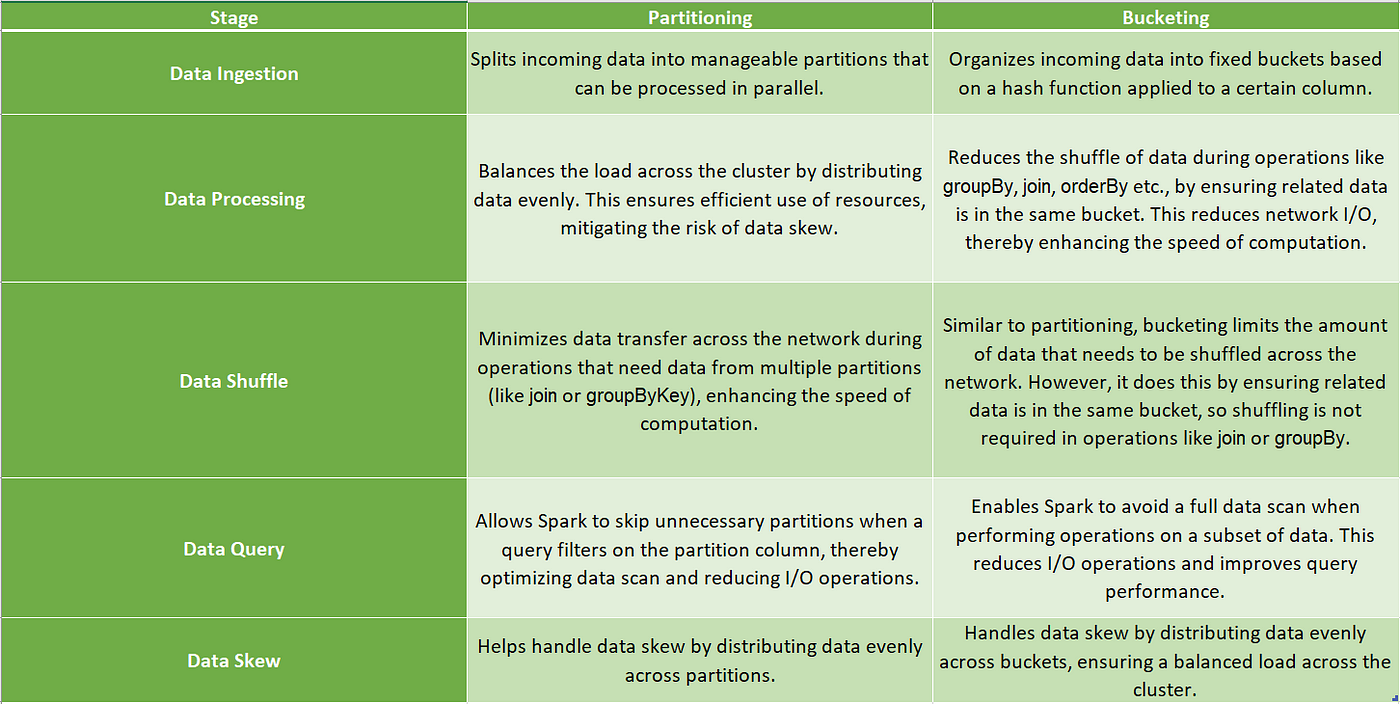

In [12]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('partition-bucket-app').getOrCreate()
df = spark.createDataFrame(
    [("person_1", "20", "M"),
     ("person_2", "56", "F"),
     ("person_3", "89", "F"),
     ("person_4", "40", "M")],
    ["name","age", "sex"]
)

In [14]:
df.write.mode("overwrite").partitionBy("sex").parquet("data/output")

In [15]:
rdd1 = spark.sparkContext.parallelize(range(1,10))
# rdd1 = rdd1.repartition(7)
rdd1.getNumPartitions()

2

In [18]:
# Load the Disney Plus dataset
disney_df = spark.read \
  .format("csv") \
  .option("header", "true") \
  .option("inferSchema", "true") \
  .option("multiline", "true") \
  .option("quote", "\"") \
  .option("escape", "\"") \
  .load("/disney_plus_shows.csv")

# Examine the current schema
disney_df.printSchema()

root
 |-- imdb_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- plot: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rated: string (nullable = true)
 |-- year: string (nullable = true)
 |-- released_at: string (nullable = true)
 |-- added_at: string (nullable = true)
 |-- runtime: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- director: string (nullable = true)
 |-- writer: string (nullable = true)
 |-- actors: string (nullable = true)
 |-- language: string (nullable = true)
 |-- country: string (nullable = true)
 |-- awards: string (nullable = true)
 |-- metascore: string (nullable = true)
 |-- imdb_rating: string (nullable = true)
 |-- imdb_votes: string (nullable = true)



In [19]:
from pyspark.sql.functions import col, to_date, regexp_replace
from pyspark.sql.types import IntegerType, FloatType

# Convert string columns to appropriate numeric types
disney_optimized_df = disney_df \
  .withColumn("year", col("year").cast(IntegerType())) \
  .withColumn("runtime_minutes",
    regexp_replace(col("runtime"), " min", "").cast(IntegerType())) \
  .withColumn("metascore_numeric", col("metascore").cast(IntegerType())) \
  .withColumn("imdb_rating_numeric", col("imdb_rating").cast(FloatType())) \
  .withColumn("imdb_votes_numeric",
    regexp_replace(col("imdb_votes"), ",", "").cast(IntegerType())) \
  .withColumn("released_date", to_date(col("released_at"))) \
  .withColumn("added_date", to_date(col("added_at")))

# Show the optimized schema
disney_optimized_df.printSchema()

root
 |-- imdb_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- plot: string (nullable = true)
 |-- type: string (nullable = true)
 |-- rated: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- released_at: string (nullable = true)
 |-- added_at: string (nullable = true)
 |-- runtime: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- director: string (nullable = true)
 |-- writer: string (nullable = true)
 |-- actors: string (nullable = true)
 |-- language: string (nullable = true)
 |-- country: string (nullable = true)
 |-- awards: string (nullable = true)
 |-- metascore: string (nullable = true)
 |-- imdb_rating: string (nullable = true)
 |-- imdb_votes: string (nullable = true)
 |-- runtime_minutes: integer (nullable = true)
 |-- metascore_numeric: integer (nullable = true)
 |-- imdb_rating_numeric: float (nullable = true)
 |-- imdb_votes_numeric: integer (nullable = true)
 |-- released_date: date (nullable = true)
 |-- added_da

In [20]:
disney_df.show(3)

+---------+--------------------+--------------------+------+-----+-----+-----------+-----------------+-------+--------------------+-------------+--------------------+--------------------+----------------+---------------+--------------------+---------+-----------+----------+
|  imdb_id|               title|                plot|  type|rated| year|released_at|         added_at|runtime|               genre|     director|              writer|              actors|        language|        country|              awards|metascore|imdb_rating|imdb_votes|
+---------+--------------------+--------------------+------+-----+-----+-----------+-----------------+-------+--------------------+-------------+--------------------+--------------------+----------------+---------------+--------------------+---------+-----------+----------+
|tt0147800|10 Things I Hate ...|A pretty, popular...| movie|PG-13| 1999|31 Mar 1999|November 12, 2019| 97 min|Comedy, Drama, Ro...|   Gil Junger|Karen McCullah, K...|Heath Led

## Understanding Partitioning with Disney Data

Partitioning divides your dataset into separate folders based on column values, which allows Spark to skip entire sections of data when filtering. Think of it like organizing books in a library by genre - when you want a mystery novel, you don't need to search through the romance or science fiction sections.

### Practical Partitioning Example: By Content Type

Since Disney Plus has both movies and TV shows, partitioning by the `type` column makes sense for queries that frequently filter by content type:

In [22]:
# Partition the Disney dataset by content type (Movie/TV Show)
disney_optimized_df.write \
  .mode("overwrite") \
  .partitionBy("type") \
  .parquet("/disney_partitioned_by_type")

# Read the partitioned data back
disney_partitioned = spark.read.parquet("/disney_partitioned_by_type")

In [34]:
movies_2020 = disney_partitioned \
  .filter((col("type") == "movie") & (col("year") == 2020)).select("title")

In [35]:
movies_2020.explain()

== Physical Plan ==
*(1) Project [title#403]
+- *(1) Filter (isnotnull(year#406) AND (year#406 = 2020))
   +- *(1) ColumnarToRow
      +- FileScan parquet [title#403,year#406,type#426] Batched: true, DataFilters: [isnotnull(year#406), (year#406 = 2020)], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/disney_partitioned_by_type], PartitionFilters: [isnotnull(type#426), (type#426 = movie)], PushedFilters: [IsNotNull(year), EqualTo(year,2020)], ReadSchema: struct<title:string,year:int>




In [ ]:
movies_2020.explain(mode="cost")